In [135]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from signature_pricing_cpp import *
import signature_pricing_py as pricing_py
import signature_core_py as core_py
from signature_core import *
from processes import *

plt.rcParams['figure.dpi'] = 100
generate_new_images = False
np.random.seed(0xDEADBEEF)

# 1 - Data preparation

* Call & put prices for multiple maturities
* Risk-free rate
* Yield Curve

In [137]:
calls_opts = pd.read_csv("data/calls_opt.csv")
puts_opts = pd.read_csv("data/puts_opt.csv")
yield_curve = pd.read_csv("data/sofr_yield_curve.csv")
spx_prices = pd.read_csv("data/spx_prices.csv")

In [138]:
spx_prices["Datetime"] = pd.to_datetime(spx_prices["Datetime"]).dt.tz_convert("UTC")
calls_opts["lastTradeDate"] = pd.to_datetime(calls_opts["lastTradeDate"]).dt.tz_convert("UTC")

calls_opts = calls_opts.sort_values("lastTradeDate")
spx_prices = spx_prices.sort_values("Datetime")

calls_opts = pd.merge_asof(calls_opts, spx_prices, left_on="lastTradeDate", right_on="Datetime")
calls_opts = calls_opts[~pd.isna(calls_opts["Datetime"])]

q = 1.0 / 100.0 # yearly dividend yield SPX

In [139]:
calls_opts.columns

Index(['Unnamed: 0', 'contractSymbol', 'lastTradeDate', 'strike', 'lastPrice',
       'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency',
       'expirationDate', 'DTE', 'underlyingPrice', 'Datetime', 'Open', 'High',
       'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'],
      dtype='object')

In [140]:
calls_opts = calls_opts[[
    "lastTradeDate", "strike", "bid", "ask", "lastPrice", "impliedVolatility", "inTheMoney", "underlyingPrice", "expirationDate", "currency", "contractSize", "volume",
    "Datetime", "Open", "Low", "Close", "Volume", "Dividends", "Stock Splits", "High"
]]

calls_opts = calls_opts.rename(columns={
    "lastTradeDate": "opt_trade_date",
    "lastPrice": "opt_last_price",
    "impliedVolatility": "yahoo_iv",
    "expirationDate": "expiration",
    "contractSize": "contract_size",
    "underlyingPrice": "spx_day",
    "Datetime": "spx_datetime",
    "Open": "spx_open",
    "Low": "spx_low",
    "High": "spx_high",
    "Close": "spx_close",
    "Volume": "spx_volume",
    "Dividends": "dividends",
    "Stock Splits": "stock_splits"
})

In [141]:
df = calls_opts.copy()

df["expiration"] = pd.to_datetime(df["expiration"], utc=True)
df["maturity"] = (df["expiration"] - df["opt_trade_date"]).dt.days / 365.0
df["spot"] = (df["spx_open"] + df["spx_close"]) / 2
df["moneyness"] = df["strike"] / df["spot"]
df["option_price"] = (df["bid"] + df["ask"]) / 2

# Filter out options with maturities that are too long or too short
df["filter"] = (df["maturity"] <= 2.0) & (df["maturity"] >= 21/365)

# Filter out 'extreme' moneyness
df["filter"] &= (df["moneyness"] >= 0.7) & (df["moneyness"] <= 1.3)

# Filter out non-liquid options
df["filter"] &= df["volume"] >= 50
df["filter"] &= df["bid"] > 0
df["filter"] &= (df["opt_trade_date"].max() - df["opt_trade_date"]).dt.days <= 0.5

df = df[df["filter"]]

# 2 - Market implied volatilities

* Construct the yield curve
* Compute market IV for multiple maturities
* IV ploting

In [142]:
def call_price(risk_free_rate, maturity, K, S, volatility):
    d1 = (np.log(S / K) + (risk_free_rate + 0.5*volatility**2)*maturity) / (volatility*np.sqrt(maturity))
    d2 = d1 - volatility*np.sqrt(maturity)
    return S*scipy.stats.norm.cdf(d1) - K*np.exp(-risk_free_rate*maturity)*scipy.stats.norm.cdf(d2)

def put_price(risk_free_rate, maturity, K, S, volatility):
    return call_price(risk_free_rate, maturity, K, S, volatility) - S + K*np.exp(-risk_free_rate*maturity)

def vega(risk_free_rate, maturity, K, S, volatility):
    d1 = (np.log(S / K) + (risk_free_rate + 0.5*volatility**2)*maturity) / (volatility*np.sqrt(maturity))
    return S * np.sqrt(maturity) * scipy.stats.norm.pdf(d1)

def newton_iv(time_to_maturity, risk_free_rate, strike, price, option_price):
    x0 = 0.2
    tolerance = 1e-7
    maxiter = 200

    x1 = x0
    for _ in range(maxiter):
        f = call_price(risk_free_rate, time_to_maturity, strike, price, x0) - option_price
        v = vega(risk_free_rate, time_to_maturity, strike, price, x0)
        if abs(v) < 1e-14:
            break
        x1 = x0 - f / v
        if abs(x1 - x0) <= tolerance * abs(x1):
            return x1
        x0 = x1
    
    return x1

In [143]:
def implied_volatility(time_to_maturity, risk_free_rate, strike, price, option_price, tol=0.01):
    def target(x):
        diff = call_price(risk_free_rate, time_to_maturity, strike, price, np.exp(x)) - option_price
        return np.log( diff**2 )
    res = scipy.optimize.minimize(target, x0=np.log(0.20), tol=tol, method="L-BFGS-B", bounds=[(-7.0, 0.0)])
    return np.exp(res.x)

In [144]:
rates = np.interp(range(0, yield_curve["Days"].max()), yield_curve["Days"], yield_curve["Rate"])

df["rate"] = np.nan
df_rates = df["rate"].to_numpy()
for i, t in enumerate( df["maturity"] ):
    if t > 2.0:
        continue
    df_rates[i] = rates[int(t*365)]
df["rate"] = df_rates

Text(0, 0.5, 'Rate (%)')

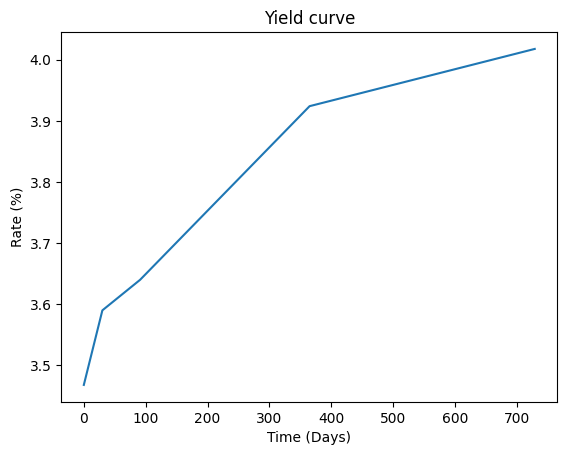

In [145]:
plt.plot(rates*100)
plt.title("Yield curve")
plt.xlabel("Time (Days)")
plt.ylabel("Rate (%)")

In [146]:
implied_vols = []
for _, row in df.iterrows():
    iv = newton_iv(row["maturity"], row["rate"] - q, row["strike"], row["spot"], row["option_price"])
    if iv > 1:
        iv = 1
    if iv < 0.0001:
        iv = 0.0001
    implied_vols.append(iv)
df["iv"] = np.array(implied_vols)

In [147]:
errors_yahoo_iv = []
errors_iv = []
iv_error_filter = []
for _, row in df.iterrows():
    iv_call_diff = call_price(row["rate"] - q, row["maturity"], row["strike"], row["spot"], row["iv"]) - row["option_price"]
    yahoo_iv_call_diff = call_price(row["rate"] - q, row["maturity"], row["strike"], row["spot"], row["yahoo_iv"]) - row["option_price"]
    errors_yahoo_iv.append(yahoo_iv_call_diff)
    errors_iv.append(iv_call_diff)
    iv_error_filter.append( abs(iv_call_diff) < 100 )

df["iv_error"] = errors_iv
df["yahoo_iv_error"] = errors_yahoo_iv
df = df[iv_error_filter]

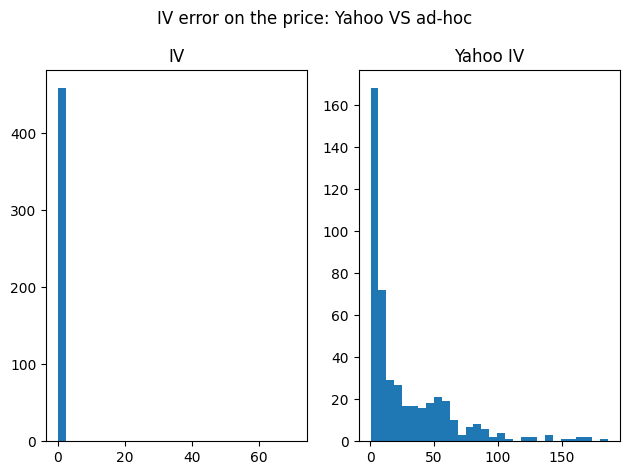

In [148]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)

ax1.hist(df["iv_error"], bins=30)
ax1.set_title("IV")

ax2.hist(df["yahoo_iv_error"], bins=30)
ax2.set_title("Yahoo IV")

fig.suptitle("IV error on the price: Yahoo VS ad-hoc")
plt.tight_layout()

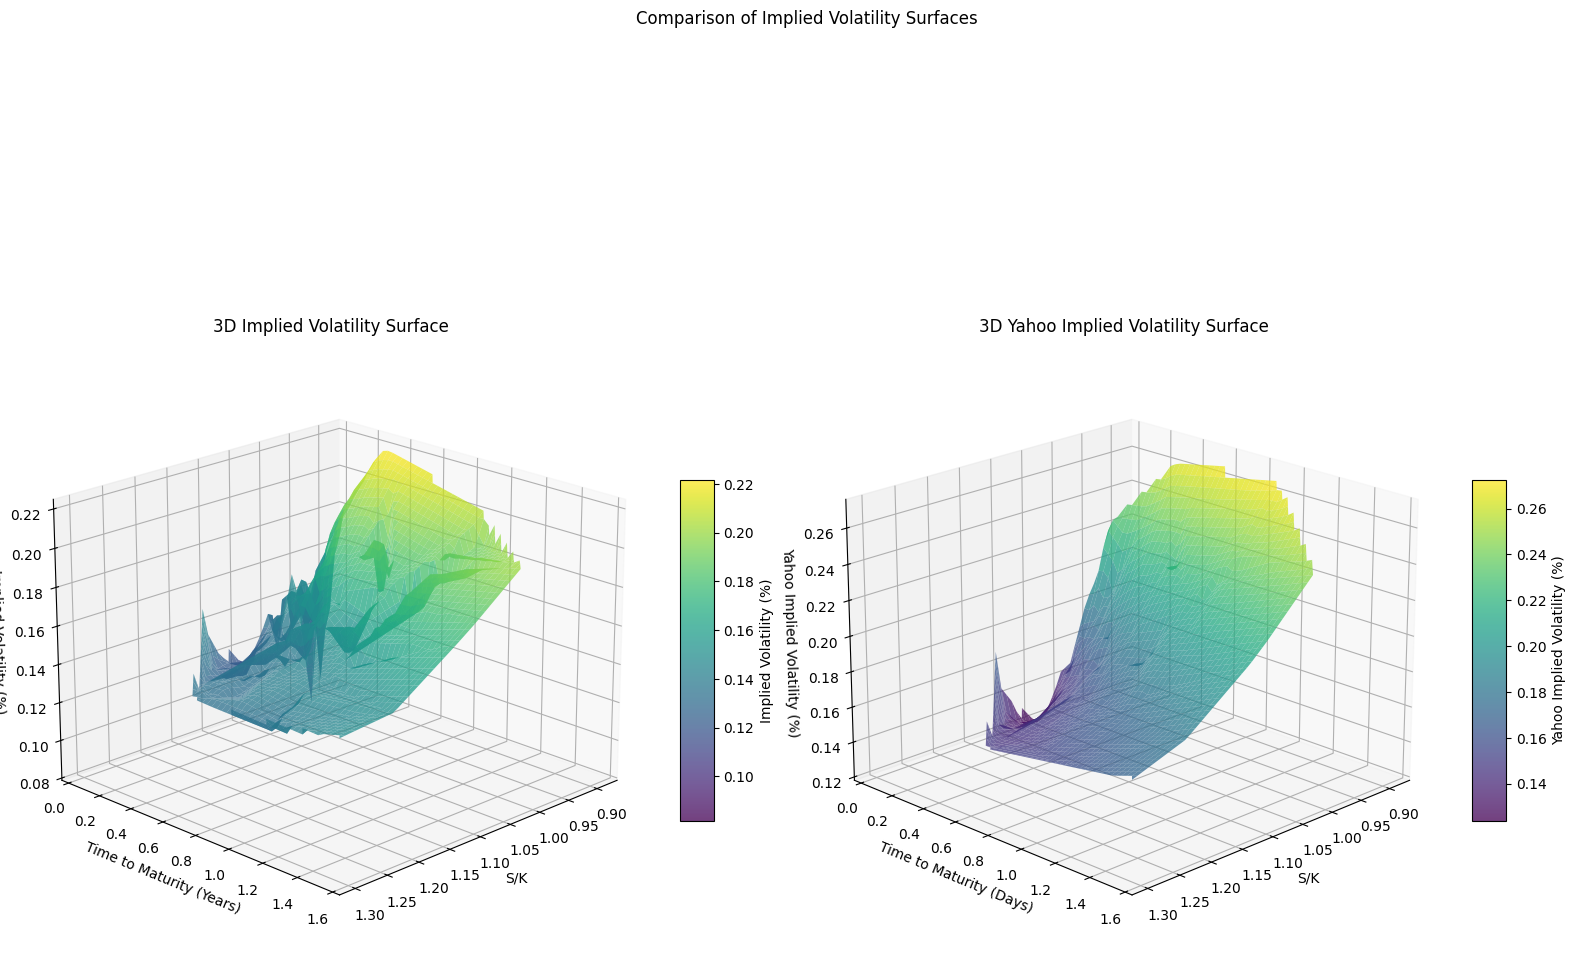

In [149]:

# Create grids
moneyness_grid = np.linspace(df["moneyness"].min(), df["moneyness"].max(), 50)
maturity_grid = np.linspace(df["maturity"].min(), df["maturity"].max(), 50)
moneyness_mesh, maturity_mesh = np.meshgrid(moneyness_grid, maturity_grid)

# Interpolate for both implied_vols and yahoo_iv
vol_grid = scipy.interpolate.griddata(
    (df["moneyness"], df["maturity"]),
    df["iv"],
    (moneyness_mesh, maturity_mesh),
    method="linear"
)

vol_grid_yahoo = scipy.interpolate.griddata(
    (df["moneyness"], df["maturity"]),
    df["yahoo_iv"],
    (moneyness_mesh, maturity_mesh),
    method="linear"
)

# Create a figure with two subplots side by side
fig = plt.figure(figsize=(16, 12))

# First subplot: Implied Volatility
ax1 = fig.add_subplot(121, projection="3d")
surface1 = ax1.plot_surface(
    moneyness_mesh,
    maturity_mesh,
    vol_grid,
    cmap="viridis",
    edgecolor="none",
    alpha=0.75
)
ax1.set_xlabel("S/K")
ax1.set_ylabel("Time to Maturity (Years)")
ax1.set_zlabel("Implied Volatility (%)")
fig.colorbar(surface1, ax=ax1, shrink=0.3, aspect=10, label="Implied Volatility (%)")
ax1.view_init(elev=20, azim=45)
ax1.set_title("3D Implied Volatility Surface")

# Second subplot: Yahoo Implied Volatility
ax2 = fig.add_subplot(122, projection="3d")
surface2 = ax2.plot_surface(
    moneyness_mesh,
    maturity_mesh,
    vol_grid_yahoo,
    cmap="viridis",
    edgecolor="none",
    alpha=0.75
)
ax2.set_xlabel("S/K")
ax2.set_ylabel("Time to Maturity (Days)")
ax2.set_zlabel("Yahoo Implied Volatility (%)")
fig.colorbar(surface2, ax=ax2, shrink=0.3, aspect=10, label="Yahoo Implied Volatility (%)")
ax2.view_init(elev=20, azim=45)
ax2.set_title("3D Yahoo Implied Volatility Surface")

plt.suptitle("Comparison of Implied Volatility Surfaces", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Assuming df is your DataFrame with columns: moneyness, maturity, iv

# Create grids
moneyness_grid = np.linspace(df["moneyness"].min(), df["moneyness"].max(), 50)
maturity_grid = np.linspace(df["maturity"].min(), df["maturity"].max(), 50)
moneyness_mesh, maturity_mesh = np.meshgrid(moneyness_grid, maturity_grid)

# Interpolate for implied_vols
vol_grid = scipy.interpolate.griddata(
    (df["moneyness"], df["maturity"]),
    df["iv"],
    (moneyness_mesh, maturity_mesh),
    method="linear"
)

# Create the 3D plot
fig = go.Figure(data=[
    go.Surface(
        z=vol_grid,
        x=moneyness_mesh,
        y=maturity_mesh,
        colorscale="Viridis",
        colorbar=dict(title="Implied Volatility (%)")
    )
])

# Update layout
fig.update_layout(
    title="3D Implied Volatility Surface",
    scene=dict(
        xaxis_title="S/K",
        yaxis_title="Time to Maturity (Years)",
        zaxis_title="Implied Volatility (%)"
    ),
    width=800,
    height=600
)

# Display in notebook (optional)
fig.show()

# 3 - Calibration

* Fit a signature using IVs
* Plot Market IVs v.s. Signature IV

In [155]:
truncation = 4
rk_subdvs = 10
int_subdvs = 20
cpp_cache = compute_shuffle_cache(truncation)

In [156]:
def objective_function(x: np.array) -> float:
    # 1. Unpack parameters
    rho = x[0]
    model_sig = Sig2D(truncation, x[1:])
    
    # 2. Extract dataframe vectors to avoid row-by-row conversion overhead
    spots = df["spot"].to_numpy()
    maturities = df["maturity"].to_numpy()
    strikes = df["strike"].to_numpy()
    market_ivs = df["iv"].to_numpy()
    rates = df["rate"].to_numpy()

    # 3. Single loop for pricing (Pre-allocating arrays)
    n = len(df)
    implied_vols = np.empty(n)
    
    for i in range(n):
        # Compute signature model price
        model_price = european_call_sig(
            spots[i], maturities[i], strikes[i], 
            model_sig, rho, 
            trunc=truncation, rk_subdivs=rk_subdvs, 
            integral_subdivs=int_subdvs, cache=cpp_cache
        )
        
        # Invert to IV immediately 
        iv = newton_iv(maturities[i], rates[i] - q, strikes[i], spots[i], model_price)
        
        # Penalize bad parameters smoothly instead of hard clipping if possible,
        # but if keeping boundaries, keep them vectorized/fast
        implied_vols[i] = max(0.0001, min(iv, 1.0))

    # 4. Vectorized Mean Squared Error
    loss = np.mean((market_ivs - implied_vols) ** 2)

    return loss

In [157]:
objective_function(np.zeros( (-1+2**5 + 1,)))

0.11189959001267975

# Plots

In [154]:
# ...